# System-Level Experimental Evaluation and Performance Analysis

## Note: Run all cells in sequence to see results and graphs.
----

I utilized two controlled and secure virtual machines to run a real-world simulation of this pipeline, to assess operability and evaluate its components' performance and value-added.

**Disclaimer**: Some variables in these experiments have been renamed in the latest version of the system code for generalization (e.g., intrusion -> event_triggered), without any change in the system logic (just variable renaming).


----
## A. Experiment 1: Edge-only vs. Cloud-only (Edge Intelligence value: Bandwidth Saving and Latency-Accuracy Trade-off)

I ran two analytics queries for the same video (data/experiment_sample.mp4), isolating where inference takes place.


**Constants:**
| Constant              | Value / meaning |
|-----------------------|----------------|
| skip_interval         | 0 = process every frame |
| heuristic_threshold   | 5.0 = default heuristic change detector |
| video                 | same test video file for both runs (data/experiment_sample.mp4) |

**Edge-only run:**
To force all frames to be processed strictly on the edge I adjusted the following variable:
- `edge_conf_threshold = -1` (lower than the minimum possible), so `(max(confidences) < -1)` is always false: don’t send to the cloud.
- I amended the default logic which sent frames to the cloud automatically if the edge failed to detect anything, i.e., `if not confidences_list: dont send_to_cloud`, to keep the frame locally even if the edge failed to detect.

**Cloud-only run:**
To force the pipeline to send all claims to the cloud I implemented the following adjustments:
- `edge_conf_threshold = 1.1` (higher than the maximum possible), so `(max(confidences) < 1.1)` is always True → always send to the cloud.
- Maintained the default logic in sending frames to the cloud when the edge fails to detect objects (`if not confidences_list: send_to_cloud`).


In [ ]:
import matplotlib.pyplot as plt

from e_utilities import (build_dataframe,
                         edge_cloud_comparison,
                         align_data,
                         plot_time_series,
                         heuristic_filter_comparison
                         )


### A.1 CLoud-only Detection

### **Data**

In [ ]:
cloud_only = build_dataframe("../experiments/vms_cloud_only/metrics_history.json")

cloud_only.head()

In [ ]:
cloud_only.describe()



#### **Final Snapshot Metrics**

**Total frames processed**

In [ ]:
cloud_only[-1:]["total_frames_processed"]

**Frames sent to the cloud**

In [ ]:
cloud_only[-1:]["frames_sent_to_cloud"]

**Total data sent/ bandwidth usage (MB)**

In [ ]:
cloud_mb = cloud_only[-1:]["mb_sent_to_cloud"]

cloud_mb

**Heuristic filter drop ratio**

In [ ]:
cloud_only[-1:]["heuristic_drop_ratio"]

**Cloud avoidance ratio**

In [ ]:
cloud_only[-1:]["cloud_avoidance_ratio"]

**Note**

This is due to the 5.0 default heuristic filter = heuristic drop ratio. Meaning all frames, that were not dropped heuristically were send to the cloud for processing.

----

**Latency (avg round-trip)**

In [ ]:
cloud_only[-1:]["avg_rt_ms"]

**Edge gateway avg infer time (ms)**

In [ ]:
cloud_only[-1:]["avg_edge_inference_ms"]

**Important Note**

Edge model serves as a decision gateway in this setup, the decision is always send to the cloud. This doesn't impact the round-trip latency of the cloud server, as the round-tip latency is measured after this gateway.

---------------------
-------

### A.2 Edge-only Detection

### **Data**

In [ ]:
edge_only_raw = build_dataframe("../experiments/vms_edge_only/metrics_history.json")
edge_only_raw.head()

In [ ]:
edge_only_raw.describe()

#### Drop the older run entries

**Why** I conducted two runs for edge-only configuration (total of 4556 history entries). The first one was inaccurate, due to frame leakages to the cloud through  this logic gate `(if not confidences_list: send_to_cloud)` in cloud decision, resulted in sending few frames to the cloud. I corrected it in the second run.

In [ ]:
edge_only_raw.drop(edge_only_raw.index[:2278], inplace=True)
# Drop old run logs
edge_only_raw.reset_index(drop=True, inplace=True)

edge_only = edge_only_raw

In [ ]:
edge_only.head()

In [ ]:
edge_only.describe()


#### **Final  Snapshot Metrics**

**Total frames processed**

In [ ]:
edge_only[-1:]["total_frames_processed"]

**Frames sent to the cloud**

In [ ]:
edge_only[-1:]["frames_sent_to_cloud"]

**Total data sent/ bandwidth usage (MB)**

In [ ]:
edge_mb = edge_only[-1:]["mb_sent_to_cloud"]

edge_mb

**Heuristic filter drop ratio**

In [ ]:
edge_only[-1:]["heuristic_drop_ratio"]

**Cloud avoidance ratio**

In [ ]:
edge_only[-1:]["cloud_avoidance_ratio"]

**Note**

Zero frames send to the cloud, all processed locally on-edge.


**2.6 Latency (avg round-trip)**

In [ ]:
edge_only[-1:]["avg_rt_ms"]

**Average edge infer time latency**

In [ ]:
edge_only[-1:]["avg_edge_inference_ms"]

**Observation**

Zero RT latency as no frames were sent to the cloud. Edge average inference time is the only latency in this scenario.

------
### Analysis:  Bandwidth usage comparison (edg-only vs. cloud-only)

In [ ]:
edge_cloud_comparison(edge_only=edge_only, cloud_only=cloud_only, )

---
### Analysis: Latency and Detection Quality (Number of objects and Accuracy)

In [ ]:
aligned_df = align_data(edge_df=edge_only, cloud_df=cloud_only)

aligned_df

In [ ]:
plot_time_series(merged_df=aligned_df, smooth_window=8)

----------------
------

--------

## B. Experiment 2: Heuristic Filter Impact

**Constants:**
| Constant              | Value / meaning |
|-----------------------|----------------|
| skip_interval         | 0 = process every frame |
| edge_conf_threshold   | 0.70 = default value |
| video                 | same test video file for both runs (data/experiment_sample.mp4) |







**Objective:**
Show how the heuristic change detection filter reduces unnecessary frame processing and cloud offloading, and improves overall efficiency.

**Datasets:**

Heuristic OFF: heuristic_threshold = 0 (process all frames).

Heuristic ON default: heuristic_threshold = 5 (process only significant changes).





### B.1 Heuristic filter OFF (value 0)

### **Data**

In [ ]:
heuristic_off_df = build_dataframe("../experiments/vms_heuristic_off_0.0/metrics_history.json")

In [ ]:
heuristic_off_df.head()

In [ ]:
heuristic_off_df.describe()


### Final Snapshot Metrics

**Heuristic filter drop ratio**

In [ ]:
heuristic_off_df[-1:]["heuristic_drop_ratio"]


**Number of frames heuristically dropped**

In [ ]:
heuristic_off_df[-1:]["heuristic_frames_dropped"]

**Rationale:**

**Why 1?** When the orchestrator initializes the heuristic filter, the logic skips further processing for the first frame using (if first frame: continue), meaning no object detection is performed on the first frame. This is because the heuristic requires two frames to compute the difference, so the first frame is only stored as a reference to compare with the second frame. However, this first frame is still counted in the total processed frames. Since no detection is performed on it. It appears as a “dropped” frame in the statistics, where: (Heretic dropped = total processed – total underwent object detection) in this case. So, even with the heuristic filter switched off (threshold = 0), there will always be 1 heuristically ignored/dropped frame due to the initialization logic.


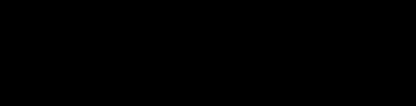
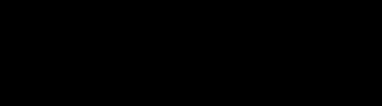
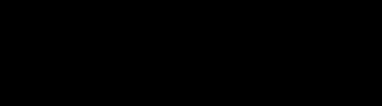
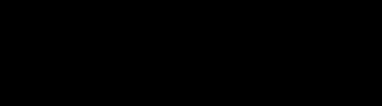
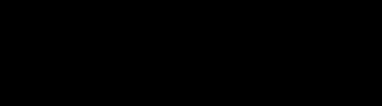
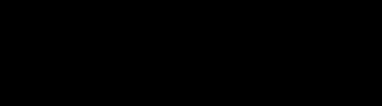

**Total frames processed**


In [ ]:
heuristic_off_df[-1:]["total_frames_processed"]

**Total bandwidth usage (MB)**

In [ ]:
heuristic_off_df[-1:]["mb_sent_to_cloud"]

**Frames sent to the cloud**

In [ ]:
heuristic_off_df[-1:]["frames_sent_to_cloud"]

-----
### B.2 Heuristic filter ON (default value 5.0)

In [ ]:
heuristic_on_df = build_dataframe("../experiments/vms_heuristic_default_5.0/metrics_history.json")
heuristic_on_df

**Heuristic filter drop ratio**

In [ ]:
heuristic_on_df[-1:]["heuristic_drop_ratio"]

**Number of frames heuristically dropped**

In [ ]:
heuristic_on_df[-1:]["heuristic_frames_dropped"]

**Total frames processed**


In [ ]:
heuristic_on_df[-1:]["total_frames_processed"]

**Total bandwidth usage (MB)**

In [ ]:
heuristic_on_df[-1:]["mb_sent_to_cloud"]

**Frames sent to the cloud**

In [ ]:
heuristic_on_df[-1:]["frames_sent_to_cloud"]

**Observation**

The heuristic filter value range is 0-255, setting it to a small value provided huge gains in terms of reduced workload ~ %55 less workload.

-----

### Analysis: Heuristic filter on/off comparison

In [ ]:
heuristic_filter_comparison(heuristic_on_df=heuristic_on_df,heuristic_off_df=heuristic_off_df)

--------------